<center><b><h4>If this notebook was helpful to you in any way, then please do consider leaving your valuable feedback that can help me improve-it would mean a lot! :)</b></center>

# Libraries and Modules

The following libraries and modules are imported at the beginning of the notebook:

- `numpy`: a library for numerical computing in Python
- `pandas`: a library for data manipulation and analysis
- `os`: a module for interacting with the operating system

- `matplotlib.pyplot`: a module for creating visualizations in Python
- `PIL.Image`: a module for working with images in Python
- `torch`: a library for machine learning in Python
- `torch.nn`: a module for building neural networks in PyTorch
- `torch.optim`: a module for optimizing neural networks in PyTorch
- `torch.nn.functional`: a module for applying various functions to tensors in PyTorch
- `torchvision`: a library for computer vision tasks in PyTorch
- `torchvision.models`: a module containing pre-trained models for computer vision tasks in PyTorch
- `torch.utils.data`: a module for working with datasets in PyTorch


In [1]:
%matplotlib inline

# Importing necessary libraries and modules
import numpy as np # for numerical computing
import pandas as pd # for manipulation and analysis
import os # for interacting with the operating system 
import matplotlib.pyplot as plt # for creating visualizations
from PIL import Image # for working with images

import torch # for machine learning
import torch.nn as nn # for building neural networks in PyTorch
import torch.optim as optim # for optimizing neural networks in PyTorch
import torchvision # for computer vision tasks in PyTorch
from torchvision import models, transforms # for loading and preprocessing image data
import torchvision.models as models # for using pre-trained models in PyTorch
from torch.utils.data import DataLoader, Dataset # for working with datasets in PyTorch


<br><br>
# Setting Things Up
We will first install torchview library, which we would later use to visualize our CNN network


In [2]:
!pip install torchview


In [3]:
import torchview

Now, we define the file paths we would be using as part of this notebook

In [4]:
# Defining the paths for the training and testing data
base_dir = '../input/'
train_csv = '../input/digit-recognizer/train.csv'
test_csv = '../input/digit-recognizer/test.csv'


# Set the device which we will be using for the model
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


Finally, we define custom dataset class for loading and preprocessing image data. It includes several functions for working with image files and applying transformations to the images.


The `manualDataset` class is defined with several parameters, including the file paths for the images, the split between training and testing data, and whether or not to use a validation split. The class includes functions for loading and preprocessing the image data, including applying transformations to the images and extracting the labels from the file names.


The `__init__()` function initializes the class with the specified parameters and defines the transformations to be applied to the images. The `__len__()` function returns the length of the dataset, and the `__getitem__()` function loads and preprocesses the image data and returns it along with the corresponding label.

In [5]:



# Defining a custom dataset class for loading and preprocessing image data
class manualDataset(Dataset):
    def __init__(self, file_path, split='train', val_split=False):
        df = pd.read_csv(file_path)
        self.split = split
        self.val_split = val_split
        if self.split=='test' and val_split==False :
            # test data
            self.raw_files = df.values.reshape((-1,28,28)).astype(np.uint8)[:,:,:,None]
            self.labels = None
        else:
            # training data
            self.raw_files = df.iloc[:,1:].values.reshape((-1,28,28)).astype(np.uint8)[:,:,:,None]
            self.labels = torch.from_numpy(df.iloc[:,0].values)
        
        if(val_split):
            self.raw_files = self.raw_files[:10]
          
       
        # Defining the transformations to be applied to the images
        self.train_transform = transforms.Compose([ transforms.ToPILImage(),transforms.RandomHorizontalFlip(), transforms.ToTensor()])
        self.test_transform = transforms.Compose([ transforms.ToTensor()])
          

        
    def __len__(self):
        return len(self.raw_files)
    
    def __getitem__(self, idx):
        # Reading in the image file
        raw = self.raw_files[idx]
      
        
        # Applying the appropriate transformation based on the split
        if self.split == 'train' or self.val_split:
            raw = self.train_transform(raw)
            label = self.labels[idx]
            return raw, label
        elif self.split == 'test':
            raw = self.test_transform(raw)
            return raw
        
        
        
        


<br><br>
# Datasets and Dataloaders Setup


Now we create instances of the `manualDataset` class for the training, testing, and validation data. The `split` parameter is used to specify whether the data is for training or testing, and the `val_split` parameter is used to specify whether to use a validation split.

We then defines the batch sizes for the training and testing data, and creates instances of the `DataLoader` class for the training, testing, and validation data. The `batch_size` parameter is used to specify the number of samples per batch, and the `shuffle` parameter is used to specify whether to shuffle the training data.



In [6]:
# Creating instances of the manualDataset class for the training, testing, and validation datasets
train_dataset = manualDataset(train_csv, split='train')
test_dataset = manualDataset(test_csv, split='test')
val_dataset = manualDataset(train_csv, split='test', val_split=True)

# Defining the batch sizes for the training and testing data
train_batch_size = 32
test_batch_size = 1

# Creating instances of the DataLoader class for the training, testing, and validation data
train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size)
val_loader = DataLoader(val_dataset, batch_size=test_batch_size)


<br><br>
# Creating a Convolutional Network



In [7]:
class CNN(nn.Module):    
    def __init__(self):
        super().__init__()
        
        # CNN layers
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=1, padding=1),  # Convolutional layer with 32 output channels
            nn.BatchNorm2d(32),  # Batch normalization to normalize the outputs
            nn.ReLU(inplace=True),  # ReLU activation function for introducing non-linearity
            nn.Conv2d(32, 32, kernel_size=3, stride=1, padding=1),  # Another convolutional layer with 32 output channels
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # Max pooling layer to reduce the spatial dimensions
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # Convolutional layer with 64 output channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),  # Another convolutional layer with 64 output channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)  # Max pooling layer to reduce the spatial dimensions
        )
        
        # Fully connected layers
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.5),  # Dropout layer to prevent overfitting
            nn.Linear(64 * 7 * 7, 512),  # Fully connected layer with 512 output units
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 512),  # Another fully connected layer with 512 output units
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, 10)  # Final fully connected layer with 10 output units (corresponding to classes)
        )
        
    def forward(self, x):
        x = self.cnn(x)  # Pass the input through the CNN layers
        x = x.view(x.size(0), -1)  # Flatten the output for the fully connected layers
        x = self.classifier(x)  # Pass the flattened output through the fully connected layers
        
        return x


# Visualizing Our Model & Training Dataset
 We first visualize the CNN model that we have defined above

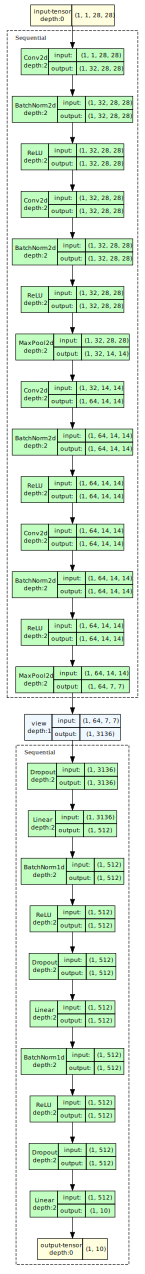

In [8]:
from torchview import draw_graph
model_graph = draw_graph(CNN(), input_size=(1,1,28,28), expand_nested=True)
model_graph.visual_graph

We also visualize the training data distribution(ie. number of values for each label)

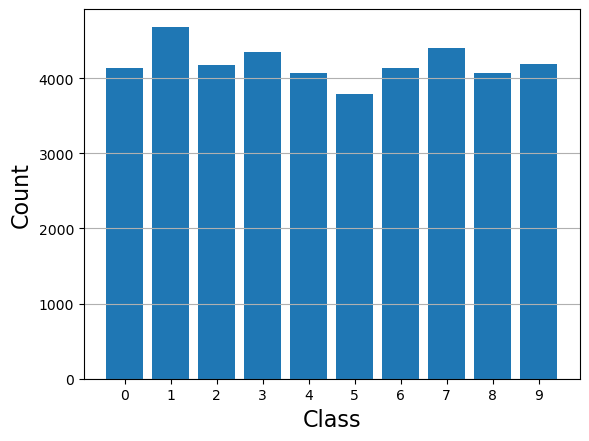

In [9]:
train_df = pd.read_csv(train_csv)
#plt.rcParams['figure.figsize'] = (8, 5)
plt.bar(train_df['label'].value_counts().index, train_df['label'].value_counts())
plt.xticks(np.arange(10))
plt.xlabel('Class', fontsize=16)
plt.ylabel('Count', fontsize=16)
plt.grid('on', axis='y')

Now, we visualize a few of the training images along with their labels

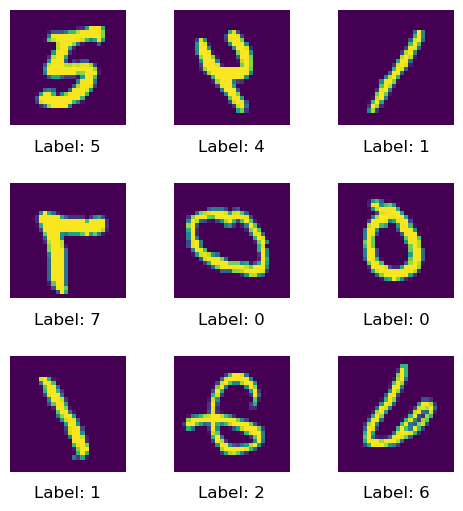

In [10]:

_,ax = plt.subplots(3,3,figsize=(6,6))
torch.manual_seed(81)
visualize_loader = DataLoader(train_dataset, batch_size=1,shuffle=True)

for i, (data,label) in enumerate(visualize_loader):
    
    
    ax[i//3][i%3].imshow(data.cpu().squeeze())
    ax[i//3][i%3].axis('off')
    ax[i//3][i%3].set_title(f"Label: {label.item()}",y=-0.3)
    if(i==8): break
plt.subplots_adjust(hspace=0.5)
plt.show()


<br><br>
## Model Setup & Training

The code begins by defining the loss function and optimizer for training the model using Cross Entropy Loss` and Stochastic gradient descent, respectively. The `params` parameter is used to specify the parameters to optimize

The number of epochs to train the model is defined using the `epochs` variable. The model is then set to training mode using `model.train()`.

The model is trained for the specified number of epochs using a nested loop. The outer loop iterates through the epochs, and the inner loop iterates through the training data using the `train_loader` DataLoader.

For each batch of data, the data and labels are moved to the appropriate device (GPU or CPU) using `to()`. The output of the model is computed using `model()`, the loss is calculated using `nn.CELoss()`, and backpropagation is performed using `backward()`. The `optimizer.step()` function is used to update the model parameters.



After training the model for each epoch, the model is set to evaluation mode using `model.eval()`. The validation data is then iterated through using the `val_loader` DataLoader object.



In [11]:
model = CNN()
model = model.to(device)
# Defining the loss function and optimizer for training the model
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(params=model.parameters(), lr=0.001, momentum=0.9)

# Defining the number of epochs to train the model
epochs = 10

# Setting the model to training mode
model.train()

# Training the model for the specified number of epochs
for epoch in range(epochs):
    epoch_loss = 0
    epoch_accuracy = 0
    
    # Iterating through the training data
    for data, label in train_loader:
        data = data.to(device)
        label = label.to(device)
        optimizer.zero_grad()
        output = model(data)
  
     
        loss = criterion(output, label)
     
      
        
        loss.backward()
        optimizer.step()
        
        epoch_loss += (loss.item())/len(train_loader)
        
    print('Epoch : {},  train loss : {}'.format(epoch+1,epoch_loss))
    
    # Setting the model to evaluation mode
    model.eval()
    with torch.no_grad():
        epoch_val_accuracy=0
        epoch_val_loss =0
        
        # Iterating through the validation data
        for data, label in val_loader:
            data = data.to(device)
            label = label.to(device)
     
            output = model(data)
           

            
            val_output = model(data)
            val_loss = criterion(val_output,label)
            
            epoch_val_loss += val_loss/ len(val_loader)
            
        print('Epoch : {} , val_loss : {}'.format(epoch+1,epoch_val_loss))


Epoch : 1,  train loss : 0.6344799383714371
Epoch : 1 , val_loss : 0.061502501368522644
Epoch : 2,  train loss : 0.11238289111515874
Epoch : 2 , val_loss : 0.00581921823322773
Epoch : 3,  train loss : 0.0640576154834848
Epoch : 3 , val_loss : 0.00838372390717268
Epoch : 4,  train loss : 0.047927403673697216
Epoch : 4 , val_loss : 0.0004655069496948272
Epoch : 5,  train loss : 0.03923117919735111
Epoch : 5 , val_loss : 0.00031889884849078953
Epoch : 6,  train loss : 0.03119567687107093
Epoch : 6 , val_loss : 0.0002302489592693746
Epoch : 7,  train loss : 0.027306878281054492
Epoch : 7 , val_loss : 5.397185668698512e-05
Epoch : 8,  train loss : 0.023451638691196843
Epoch : 8 , val_loss : 0.00017960912373382598
Epoch : 9,  train loss : 0.0187842428107011
Epoch : 9 , val_loss : 5.582453741226345e-05
Epoch : 10,  train loss : 0.01770805979958199
Epoch : 10 , val_loss : 1.240928759216331e-05


<br><br>
# Visualizing Predictions
We will visualize the first 9 predictions made by the model

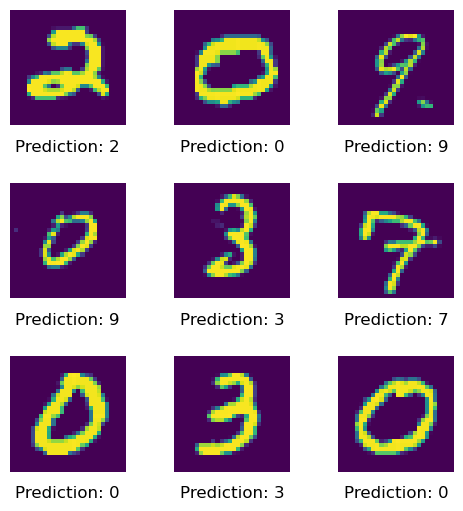

In [12]:
model.eval()
_,ax = plt.subplots(3,3,figsize=(6,6))
for i, data in enumerate(test_loader):
    
 
    data = data.cuda()

    output = model(data)
    

    pred = output.cpu().data.max(1, keepdim=True)[1]
    
    ax[i//3][i%3].imshow(data.cpu().squeeze())
    ax[i//3][i%3].axis('off')
    ax[i//3][i%3].set_title(f"Prediction: {pred.item()}",y=-0.3)
    if(i==8): break
plt.subplots_adjust(hspace=0.5)
plt.show()


<br><br>
## Submission

Finally, we inference the model on the test dataset for submission


In [13]:
model.eval()
test_pred = torch.LongTensor()

for i, data in enumerate(test_loader):
    
    if torch.cuda.is_available():
        data = data.cuda()

    output = model(data)

    pred = output.cpu().data.max(1, keepdim=True)[1]
    test_pred = torch.cat((test_pred, pred), dim=0)
    
print(test_pred.shape)
submission_df = pd.read_csv("../input/digit-recognizer/sample_submission.csv")
submission_df['Label'] = test_pred.numpy().squeeze()
submission_df.to_csv('submission.csv', index=False)

torch.Size([28000, 1])
